# nb04_v10_benchmark (headline cross-pipeline comparison)

Consolidates Phase C/D/E/F results into a unified view. Loads per-cell and ensemble CSVs from `results/` for all four pipelines (opx, cpx, twopx, universal) and produces:

1. Unified best-RMSE table
2. Cross-pipeline heatmap (headline figure)
3. Winning-base histogram (which family wins most often?)
4. Ensemble-vs-best-base delta per pipeline

**Scope:** internal ML comparison only. External models (Agreda, Jorgenson, Petrelli, Wang, Putirka) are integrated in the follow-up benchmark (Phase G.1b).


In [1]:
import os, sys
from pathlib import Path
ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))

import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from config import RESULTS
pd.set_option('display.width', 220)
pd.set_option('display.max_columns', 50)


## Load per-pipeline results

Per-cell CSVs carry one row per (model, target, track, feature_set). Ensemble CSVs carry one row per (method, target, track, feature_set).


In [2]:
pipelines = {
    'opx':       RESULTS / 'v10_opx_per_cell_results.csv',
    'cpx':       RESULTS / 'v10_cpx_per_cell_results.csv',
    'twopx':     RESULTS / 'v10_twopx_per_cell_results.csv',
    'universal': RESULTS / 'universal' / 'v10_universal_per_cell_results.csv',
}
ens_paths = {
    'opx':       RESULTS / 'v10_opx_ensemble_results.csv',
    'cpx':       RESULTS / 'v10_cpx_ensemble_results.csv',
    'twopx':     RESULTS / 'v10_twopx_ensemble_results.csv',
    'universal': RESULTS / 'universal' / 'v10_universal_ensemble_results.csv',
}

frames_base, frames_ens = [], []
for p, path in pipelines.items():
    df = pd.read_csv(path)
    df['pipeline'] = p
    frames_base.append(df)
for p, path in ens_paths.items():
    df = pd.read_csv(path)
    df['pipeline'] = p
    frames_ens.append(df)

all_bases = pd.concat(frames_base, ignore_index=True)
all_ens   = pd.concat(frames_ens, ignore_index=True)
print(f'base rows: {len(all_bases)}  ensemble rows: {len(all_ens)}')


base rows: 272  ensemble rows: 102


## Unified best-RMSE table
Per (pipeline, target, track): winning base model + winning ensemble method.


In [3]:
idx_b = all_bases.groupby(['pipeline','target','track'])['test_rmse'].idxmin()
best_b = all_bases.loc[idx_b, ['pipeline','target','track','model','feature_set','test_rmse']]
best_b = best_b.rename(columns={'model':'best_base','test_rmse':'base_rmse','feature_set':'base_fs'})

idx_e = all_ens.groupby(['pipeline','target','track'])['test_rmse'].idxmin()
best_e = all_ens.loc[idx_e, ['pipeline','target','track','method','feature_set','test_rmse']]
best_e = best_e.rename(columns={'method':'best_ens','test_rmse':'ens_rmse','feature_set':'ens_fs'})

unified = best_b.merge(best_e, on=['pipeline','target','track'], how='outer')
unified['ensemble_gain'] = unified['base_rmse'] - unified['ens_rmse']
unified = unified.sort_values(['target', 'pipeline', 'track']).reset_index(drop=True)
unified.round(3)


,pipeline,target,track,best_base,base_fs,base_rmse,best_ens,ens_fs,ens_rmse,ensemble_gain
0,cpx,P_kbar,cpx_liq,LightGBM,pwlr,6.537,ridge,pwlr,6.522,0.015
1,cpx,P_kbar,cpx_only,MLP,alr,13.466,two_level,raw,14.285,-0.819
2,opx,P_kbar,opx_liq,MLP,raw,3.816,greedy,raw,3.825,-0.010
3,opx,P_kbar,opx_only,XGB,pwlr,10.202,ridge,pwlr,10.178,0.023
4,twopx,P_kbar,twopx,XGB,alr,4.263,greedy,pwlr,4.514,-0.251
5,universal,P_kbar,universal,MLP,universal_raw,16.624,two_level,universal_raw,16.363,0.261
6,cpx,T_C,cpx_liq,CatBoost,pwlr,71.571,ridge,pwlr,68.360,3.210
7,cpx,T_C,cpx_only,ERT,pwlr,127.350,two_level,pwlr,128.882,-1.532
8,opx,T_C,opx_liq,ElasticNet,raw,77.062,greedy,raw,78.025,-0.963
9,opx,T_C,opx_only,LightGBM,alr,147.982,ridge,alr,149.577,-1.595


## Figure 1: cross-pipeline headline heatmap

Rows = (pipeline, track), columns = target. Color = best base RMSE. Lower (darker) is better.


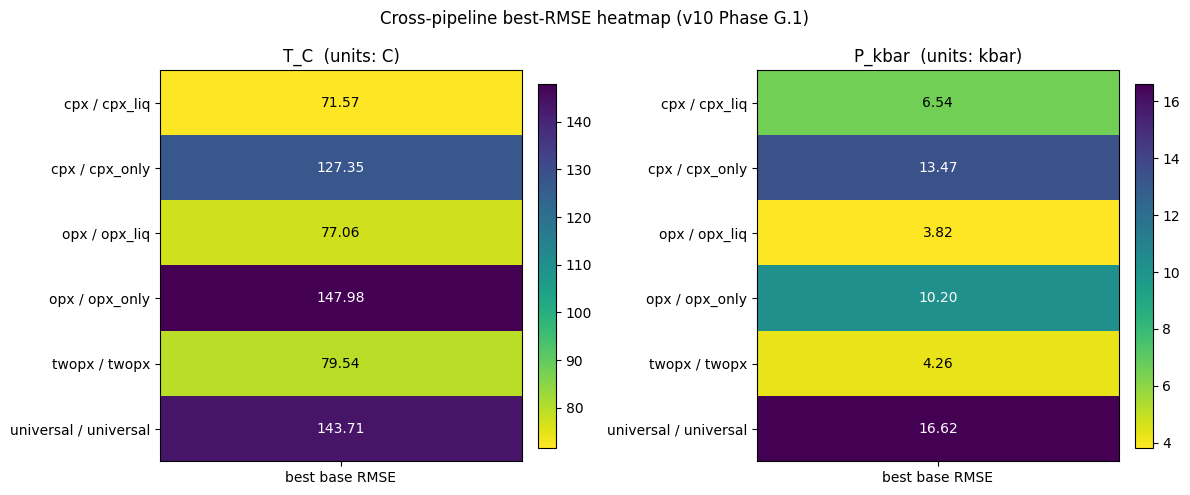

saved C:\Users\NQTa\Documents\MLCourse\Final Project\figures\fig_nb04_cross_pipeline_heatmap.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, tgt in zip(axes, ['T_C', 'P_kbar']):
    sub = unified[unified['target']==tgt].copy()
    sub['row'] = sub['pipeline'] + ' / ' + sub['track']
    rows = sub['row'].tolist()
    vals = sub['base_rmse'].values.reshape(-1, 1)
    im = ax.imshow(vals, cmap='viridis_r', aspect='auto')
    ax.set_yticks(range(len(rows)))
    ax.set_yticklabels(rows)
    ax.set_xticks([0])
    ax.set_xticklabels([f'best base RMSE'])
    for i, v in enumerate(sub['base_rmse'].values):
        ax.text(0, i, f'{v:.2f}', ha='center', va='center',
                color='white' if v > sub['base_rmse'].median() else 'black',
                fontsize=10)
    ax.set_title(f'{tgt}  (units: {"C" if tgt=="T_C" else "kbar"})')
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.suptitle('Cross-pipeline best-RMSE heatmap (v10 Phase G.1)', fontsize=12)
plt.tight_layout()
out = ROOT / 'figures' / 'fig_nb04_cross_pipeline_heatmap.png'
out.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(out, dpi=300, bbox_inches='tight')
plt.show()
print(f'saved {out}')


## Figure 2: winning base family across all 10 cells

Counts, across the 10 (pipeline, target, track) cells, how many times each base-model family wins. Signals which family to treat as the primary recommendation.


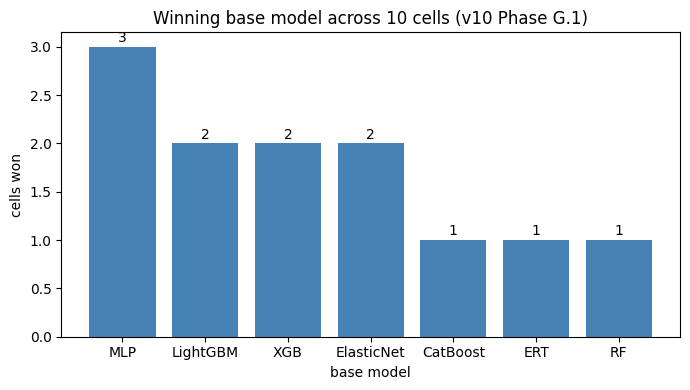

saved C:\Users\NQTa\Documents\MLCourse\Final Project\figures\fig_nb04_winning_base_histogram.png


In [5]:
win_counts = unified['best_base'].value_counts()
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(win_counts.index, win_counts.values, color='steelblue')
ax.set_ylabel('cells won'); ax.set_xlabel('base model')
ax.set_title('Winning base model across 10 cells (v10 Phase G.1)')
for i, v in enumerate(win_counts.values):
    ax.text(i, v + 0.05, str(v), ha='center', fontsize=10)
plt.tight_layout()
out = ROOT / 'figures' / 'fig_nb04_winning_base_histogram.png'
plt.savefig(out, dpi=300, bbox_inches='tight')
plt.show()
print(f'saved {out}')


## Figure 3: ensemble-vs-base delta per cell

Positive `ensemble_gain` means the ensemble beat the best single base. Near-zero or negative means the best single base was already hard to beat. Bars colored by target.


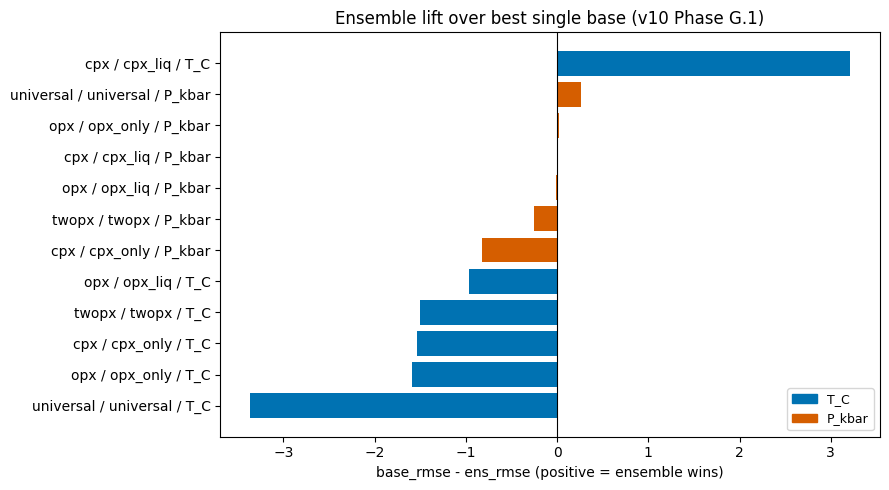

saved C:\Users\NQTa\Documents\MLCourse\Final Project\figures\fig_nb04_ensemble_lift.png


In [6]:
tmp = unified.copy()
tmp['cell'] = tmp['pipeline'] + ' / ' + tmp['track'] + ' / ' + tmp['target']
tmp = tmp.sort_values('ensemble_gain')

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#0072B2' if t == 'T_C' else '#D55E00' for t in tmp['target']]
ax.barh(tmp['cell'], tmp['ensemble_gain'], color=colors)
ax.axvline(0, color='k', lw=0.8)
ax.set_xlabel('base_rmse - ens_rmse (positive = ensemble wins)')
ax.set_title('Ensemble lift over best single base (v10 Phase G.1)')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#0072B2', label='T_C'),
                   Patch(color='#D55E00', label='P_kbar')],
          fontsize=9, loc='lower right')
plt.tight_layout()
out = ROOT / 'figures' / 'fig_nb04_ensemble_lift.png'
plt.savefig(out, dpi=300, bbox_inches='tight')
plt.show()
print(f'saved {out}')


## Summary table: written to disk

Saves the unified best-RMSE table to `results/v10_phase_g1_unified_best.csv` for downstream use by manuscript + other notebooks.


In [7]:
out_csv = RESULTS / 'v10_phase_g1_unified_best.csv'
unified.to_csv(out_csv, index=False)
print(f'saved {out_csv}')
print(f'\nShape: {unified.shape}')


saved C:\Users\NQTa\Documents\MLCourse\Final Project\results\v10_phase_g1_unified_best.csv

Shape: (12, 10)


## Next: Phase G.1b

Integrate external models (Agreda 2024 cpx-liq, Jorgenson 2022 cpx-only/cpx-liq, Petrelli 2020 cpx-only/cpx-liq, Wang 2021 cpx-liq, Putirka 2008 cpx-only/cpx-liq) on the shared ArcPL Kd-eq subset. Produces `fig_nb04_{pipeline}_method_benchmark_arcpl_kdEq.png` and the cross-method comparison headline.
